In [1]:
import os
import sys
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"
project_directory = Path.cwd()
if not (project_directory / "common.py").is_file():
    project_directory = project_directory.parent
sys.path.insert(0, str(project_directory))
from common import ROOT, MODE, SEED, BATCH, EPOCHS, CLASSES, ensure_data, split_paths, seed_all, load_array, evaluate_binary, save_metrics
seed_all()
print(f"Project: {ROOT.name} | mode: {MODE} | seed: {SEED}")


Project: land-classification-github | mode: quick | seed: 7331


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from keras_models import make_cnn
train, val, test = split_paths()
x_train, x_val, x_test = [load_array(group[0]) for group in (train, val, test)]
tf.random.set_seed(SEED)
model = make_cnn()
model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="binary_crossentropy", metrics=["accuracy"])
print("Model parameters:", model.count_params(), "| train data:", x_train.shape)


Model parameters: 23649 | train data: (336, 64, 64, 3)


In [3]:
checkpoint = ROOT / "models" / "keras_cnn.keras"
checkpoint.parent.mkdir(parents=True, exist_ok=True)
fit = model.fit(x_train, train[1], validation_data=(x_val, val[1]), epochs=EPOCHS, batch_size=BATCH, verbose=2,
    callbacks=[tf.keras.callbacks.ModelCheckpoint(checkpoint, monitor="val_loss", save_best_only=True)])
model = tf.keras.models.load_model(checkpoint)
probabilities = model.predict(x_test, verbose=0).reshape(-1)
metrics = evaluate_binary(test[1], probabilities)
print("Test metrics:", {name: value for name, value in metrics.items() if isinstance(value, (float, int))})
print(metrics["classification_report"])
print("Saved:", checkpoint.relative_to(ROOT), save_metrics("keras_cnn", metrics).relative_to(ROOT))


Epoch 1/2
21/21 - 3s - 162ms/step - accuracy: 0.5060 - loss: 0.6593 - val_accuracy: 0.5000 - val_loss: 0.6495
Epoch 2/2
21/21 - 1s - 54ms/step - accuracy: 0.7708 - loss: 0.5689 - val_accuracy: 0.8611 - val_loss: 0.4633
Test metrics: {'n_test': 72, 'accuracy': 0.9305555555555556, 'precision': 1.0, 'recall': 0.8611111111111112, 'f1': 0.9253731343283582, 'roc_auc': 0.9683641975308641, 'log_loss': 0.42762366127010915}
                  precision    recall  f1-score   support

class_0_non_agri       0.88      1.00      0.94        36
    class_1_agri       1.00      0.86      0.93        36

        accuracy                           0.93        72
       macro avg       0.94      0.93      0.93        72
    weighted avg       0.94      0.93      0.93        72

Saved: models/keras_cnn.keras results/keras_cnn.json


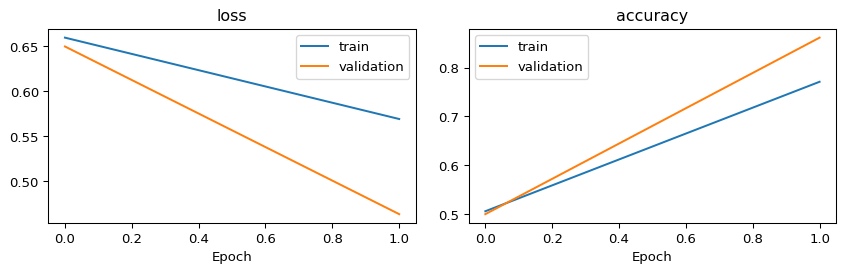

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for axis, metric in zip(axes, ("loss", "accuracy")):
    axis.plot(fit.history[metric], label="train")
    axis.plot(fit.history["val_" + metric], label="validation")
    axis.set(xlabel="Epoch", title=metric)
    axis.legend()
plt.tight_layout()
plt.show()
